In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img 
from tensorflow.keras.preprocessing.image import img_to_array 
from tensorflow.keras.applications.vgg16 import preprocess_input 

# models 
from tensorflow.keras.models import Model
from tensorflow.keras import layers

In [ ]:
from keras import backend as K
# import tensorflow as tf
jobs = 32 # it means number of cores
config = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=jobs,
                         inter_op_parallelism_threads=jobs,
                         allow_soft_placement=True,
                         device_count={'CPU': jobs})
session = tf.compat.v1.Session(config=config)
K.set_session(session)

In [1]:
import os
from os import path
from os.path import exists
import shutil
import re
from random import randint
from datetime import datetime
import time
import inspect

import math
import numpy as np
import pandas as pd
import pickle

from tqdm import tqdm

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import gaussian_kde, binned_statistic_2d
from scipy.spatial import ConvexHull

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import umap
import alphashape

### function

In [3]:
def fid2fname(fid, ftype):
    ch = dict(zip(['dic', 'nem', 'ent', 'coh', 'mch', 'den', 'dota'], ['c3', 'c3', 'c3', 'c3', 'c1', 'c1', 'c1']))
    split_arr = np.array([s.split('_') for s in fid])
    concat_arr = np.array([s[0]+'_'+s[1]+ch[ftype]+'_ORG_'+s[2]+'_'+ftype+'.tif' for s in split_arr])
    return concat_arr

def fname2fid(fname):
    split_arr = np.array([s.split('_') for s in fname])
    concat_arr = np.array([s[0]+'_'+s[1].split('c')[0]+'_'+s[3] for s in split_arr])
    return concat_arr

def get_cluster_score(feat, lab):
#     lab[(lab != 1) & (lab != 5)] = 0;
    
    filt_feat = feat[lab != 0]
    filt_lab = lab[lab != 0]
    
    slh_score = silhouette_score(filt_feat, filt_lab)
    dbs_score = davies_bouldin_score(filt_feat, filt_lab)
    chs_score = calinski_harabasz_score(filt_feat, filt_lab)
    
    return [slh_score, dbs_score, chs_score]

def get_kmeans_cluster(kmeans, feat, clust_num, overwrite):
    if overwrite == 0 and os.path.exists(km_file + '.npy'):
        print('file exist and no overwrite')
        kmlabels = np.load(km_file + '.npy')
    else:
        km = KMeans(n_clusters=clust_num, random_state=22)
        km.fit(feat)
        kmlabels = km.labels_
        np.save(km_file, kmlabels)
    return kmlabels

def get_umap_embedding(umap_file, feat, overwrite):
    if overwrite == 0 and os.path.exists(umap_file + '.npy'):
        print('file exist and no overwrite')
        embedding = np.load(umap_file + '.npy')
    else: 
        reducer = umap.UMAP()
        embedding = reducer.fit_transform(feat)
        np.save(umap_file, embedding)
    return embedding

def get_pca_features(pca_file, n_comp, feat, overwrite):
    if overwrite == 0 and os.path.exists(pca_file + '.npy'):
        print('file exist and no overwrite')
        pca_feat = np.load(pca_file + '.npy')
    else: 
        pca = PCA(n_components=n_comp)
        pca_feat = pca.fit_transform(feat)
        np.save(pca_file, pca_feat)
    return pca_feat

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap
  
def load_features_pkl(feat_fname):
    feat_file = open(feat_fname, 'rb')
    feat_dict = pickle.load(feat_file)
    feat = np.array([feat_dict[key] for key in sorted(feat_dict.keys())])
    return feat

In [4]:
def plot_umap_sp(fig, model_name, embedding, labels, score):
    my_col = {1:'blue', 2:'black', 0:'gray'}

    plt.title(model_name + "\n" + score, fontsize=10)
    
    plt.plot(embedding[labels==0,0],embedding[labels==0,1],'.',markersize=6, color=my_col[0], alpha=0.3)
    plt.plot(embedding[labels==2,0],embedding[labels==2,1],'.',markersize=12, color=my_col[2], alpha=0.5)
    plt.plot(embedding[labels==1,0],embedding[labels==1,1],'.',markersize=12, color=my_col[1], alpha=0.5)

    return(fig)

In [5]:
def load_initiation_file(ini_file, ch_type, ini_source):
    source = dict(zip(['photo', 'spon', 'bg', 'res'], ['ini', 'ini', 'bg', 'res']))
    
    df = pd.read_csv(ini_file, sep='\t')
    
    df['min_frame'] = '01'
    
    if ini_source == 'spon':
        # Group the dataframe by columns 'id' and 'well', and get the minimum value of column 'frame' for each group
        grouped = df.groupby(['id', 'well'])['frame'].min().apply(lambda x: max(x - 3, 1)).reset_index()

        # Create a dictionary from the grouped dataframe
        frame_dict = {(row['id'], row['well']): row['frame'] for _, row in grouped.iterrows()}

        df['min_frame'] = df.apply(lambda row: frame_dict[(row['id'], row['well'])], axis=1)
        
    df['well'] = df['well'].astype(str).str.zfill(2)
    df['frame'] = df['frame'].astype(str).str.zfill(2)
    df['min_frame'] = df['min_frame'].astype(str).str.zfill(2)
    df['pattern'] = df['pattern'].astype(int)
    
    df['fname'] = df['id']+'_s'+df['well']+'t'+df['min_frame']+ch_type+'_ORG'+'_'+source[ini_source]+df['index'].astype(str)+'_'+ftype+'.tif'
    df['fid'] = df['id']+'_s'+df['well']+'t'+df['min_frame']+'_'+source[ini_source]+df['index'].astype(str)

    return df

### load input data

In [6]:
imsize = 150;
ftype_flip = 'dota'
ftype = ftype_flip.split('_')[0]
flip_type = "_"+ftype_flip.split('_')[1] if '_' in ftype_flip else ''
ch = dict(zip(['dic', 'nem', 'ent', 'coh', 'mch', 'den', 'phi', 'seg', 'dot', 'dota'],
              ['c3',  'c3',  'c3',  'c3',  'c1',  'c1',  'c3',  'c1', 'c1', 'c1']))

# ini_clust_path = '/lab_home/N417/Jen-Hao/Spatiotemporal/initiation_clustering/'
ini_clust_path = 'D:/Spatiotemporal_analysis/Initiation_clustering/'

In [7]:
bg_rep = 10
res_rep = 11

# ini_path = '/lab_home/N417/Jen-Hao/Spatiotemporal/initiation/'
ini_path = 'D:/Spatiotemporal_analysis/initiation/'

### load initiation summary files
p_ini_file = ini_path + 'photoinduct-all_initiation_details_pattern_per5_cov10_sp150.txt'
p_df = load_initiation_file(p_ini_file, ch[ftype], 'photo')

s_ini_file = ini_path + 'spontaneous_initiation_details_pattern_per5_cov10_sp150.txt'
s_df = load_initiation_file(s_ini_file, ch[ftype], 'spon')

bg_file = ini_path + 'photoinduct-all_randbg' + str(bg_rep) + '_details_pattern_per5_cov10_sp150.txt'
bg_df = load_initiation_file(bg_file, ch[ftype], 'bg')

res_file = ini_path + 'photoinduct-all_resist' + str(res_rep) + '_details_pattern_per5_cov10_sp150.txt'
res_df = load_initiation_file(res_file, ch[ftype], 'res')

ini_df = pd.concat([p_df, s_df], axis=0)
df = pd.concat([p_df, s_df, bg_df, res_df], axis=0)

In [8]:
# generate fid x pattern, den, and entropy
all_fid = pd.concat([p_df.fid, s_df.fid, bg_df.fid, res_df.fid], ignore_index=True)
all_pttn = pd.concat([p_df.pattern, s_df.pattern, bg_df.pattern, res_df.pattern], ignore_index=True)
all_den = pd.concat([p_df.den, s_df.den, bg_df.den, res_df.den], ignore_index=True)
all_ent = pd.concat([p_df.ent, s_df.ent, bg_df.ent, res_df.ent], ignore_index=True)

fidXpttn = dict(zip(all_fid, all_pttn))
fidXden = dict(zip(all_fid, all_den))
fidXent = dict(zip(all_fid, all_ent))

for keys, value in fidXpttn.items():
    if '1' in str(value) and '2' in str(value): # randomly select phalf or mhalf if it is both
        fidXpttn[keys] = randint(1, 2)
    elif '1' in str(value): # phalf
        fidXpttn[keys] = 1
    elif '2' in str(value): # mhalf
        fidXpttn[keys] = 2
    elif '3' in str(value) and '4' in str(value): # splay and bind
        fidXpttn[keys] = 6
    elif '3' in str(value):
        fidXpttn[keys] = 3
    elif '4' in str(value):
        fidXpttn[keys] = 4

In [ ]:
# load photoinduction initiation image files
p_ini_path = ini_clust_path + 'photoinduct_ini_' + str(imsize) + '_rotated_10' + flip_type + '/'
all_files = os.listdir(p_ini_path)
p_ini_fnames = np.array([f for f in all_files if ftype in f])

# load spontaneous initiation image files
s_ini_path = ini_clust_path + 'photoinduct_ini_' + str(imsize) + '_rotated_10_spon' + flip_type + '/'
all_files = os.listdir(s_ini_path)
s_ini_fnames = np.array([f for f in all_files if ftype in f])

# load background image files
bg_path = ini_clust_path + 'photoinduct_randbg' + str(bg_rep) + '_' + str(imsize) + '_rotated_10' + flip_type + '/'
bg_files = os.listdir(bg_path)
bg_fnames = np.array([f for f in bg_files if ftype in f])

# load resistant region image files
res_path = ini_clust_path + 'photoinduct_resist' + str(res_rep) + '_' + str(imsize) + '_rotated_10' + flip_type + '/'
res_files = os.listdir(res_path)
res_fnames = np.array([f for f in res_files if ftype in f])

# concatenate all types of initiation files
fnames = np.concatenate((p_ini_fnames, s_ini_fnames, bg_fnames, res_fnames), axis=0)
len(fnames)

In [ ]:
# clust_path = ini_clust_path + 'photoinduct_ini_' + str(imsize) + '_bg' + str(bg_rep) + '_res' + str(res_rep) + '_rotated_10_clust/'
clust_path = ini_clust_path + 'photoinduct_ini_' + str(imsize) + '_rotated_10_clust/'
os.makedirs(clust_path, exist_ok=True)

model_sel_path = 'model_selection_'+ftype+'/'
os.makedirs(clust_path+model_sel_path, exist_ok=True)

clust_path

### load model data

In [729]:
model_dictionary = {m[0]:m[1] for m in inspect.getmembers(tf.keras.applications, inspect.isfunction)}
del model_dictionary['NASNetLarge']
del model_dictionary['ConvNeXtXLarge']

In [776]:
nem_models = 'EfficientNetV2S'
ent_models = 'EfficientNetV2B2'
mch_models = 'EfficientNetB4'
den_models = ['ResNetRS200','ResNet101V2'] #['ResNetRS420', 'ResNetRS270', 'ResNetRS200', 'ResNetRS152', 'ResNet101V2', 'ResNet50', 'MobileNetV3Small', 'MobileNetV3Large', 'MobileNetV2', 'MobileNet']
phi_models = 'ResNetRS152'
seg_models = ['DenseNet201', 'EfficientNetB4', 'RegNetX004', 'RegNetX032']
dot_models = 'InceptionV3'

# nem_models = ['EfficientNetB3', 'EfficientNetB2', 'Xception', 'EfficientNetV2S', 'EfficientNetV2B1']
# dot_models = ['InceptionV3', 'Xception', 'DenseNet201', 'DenseNet121', 'DenseNet169']

curr_models = {'nem' : nem_models, 'ent' : ent_models, 'mch': mch_models, 'phi': phi_models, 'den': den_models, 'seg': seg_models, 'dot':dot_models, 'dota':dot_models}

### run pretrained models

In [730]:
### generate features using pretrained models and save the scaled features
for model_name, base_model in tqdm(model_dictionary.items()):
    data = {}
    feat_file = clust_path + 'model_selection_'+ftype+'/' + model_name + '_scaledfeat_' + ftype_flip + '_bg_res'
    
    # skip models that do not need to be run
    if os.path.exists(feat_file + '.pkl'):
        print('skipped '+model_name)
        continue
    if model_name not in curr_models[ftype]:
        continue
        
    print(ftype_flip + ' ' + model_name)

    dim = 224
    input_shape = (dim, dim, 3) # note that NASNetLarge input shape is (331, 331, 3)
    
    try:
        pretrained_model = base_model(include_top=False, weights='imagenet', input_shape=input_shape)
      
        model = Model(inputs = pretrained_model.inputs, outputs = pretrained_model.layers[-1].output)

        for f in fnames:
            if path.exists(p_ini_path+f):
                im_path = p_ini_path
            elif path.exists(s_ini_path+f):
                im_path = s_ini_path
            elif path.exists(bg_path+f):
                im_path = bg_path
            elif path.exists(res_path+f):
                im_path = res_path
                
            img = load_img(im_path+f, target_size=(dim, dim))
            img = np.array(img) # convert from 'PIL.Image.Image' to numpy array
            reshaped_img = img.reshape(1, dim, dim, 3) # reshape the data reshape(num_samp, dim, dim, ch)
            imgx = preprocess_input(reshaped_img) # prepare image for model
            data[f] = model.predict(imgx, use_multiprocessing=True, verbose=0) # get the feature vector
    
        fid = sorted(np.array(list(data.keys())) # get a list of the filenames
        
        with open(clust_path+'fid_from_feat_pkl.txt', 'w') as f:
            f.write('\n'.join(fid)) 
        f.close()

        feat = np.array(list(data.values())) # get a list of just the features
        feat = feat.reshape(feat.shape[0],-1) # reshape so that there are num samples to num vectors

        # standardize features
        scaled_feat = []
        for ft in feat:
            ft_scaled = preprocessing.scale(ft.astype(float))
            scaled_feat.append(ft_scaled)

        # save the dictionary as pickle with filenames as keys and features as values
        feat_dict = dict(zip(fid, scaled_feat))
        with open(feat_file+'.pkl', 'wb') as handle:
            pickle.dump(feat_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)
            
    except tf.errors.ResourceExhaustedError as e:
        print(model_name + ": ResourceExhaustedError: failed to allocate memory")
        continue

  0%|                                                                                                                                                                                          | 0/69 [00:00<?, ?it/s]

dota InceptionV3


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [14:02<00:00, 12.20s/it]


### plot the clustering results

In [23]:
# establish labels for the image files

# load filenames
with open(clust_path+'fid_from_feat_pkl.txt', 'r') as f:
    fid = f.read().splitlines()
f.close()

# concatenate necessary information
lab = pd.DataFrame([fidXpttn, fidXden, fidXent]).T
lab.columns = ["pattern", "density", "entropy"]

# set up source
conditions = [lab.index.str.contains('bg'), lab.index.str.contains('res'), lab.index.str.contains('photo'), lab.index.str.contains('ini')]
selections = [-1, -2, 0, 1]

lab['source'] = np.select(conditions, selections, default=None)

# label densities into high and low
den_upper = 70.7203 + 19.6337
den_lower = 70.7203 - 19.6337

conditions = [lab['density'] > den_upper, lab['density'] < den_lower]
selections = [1, 2]

lab['den_lab'] = np.select(conditions, selections, default=0)

# label entropy into high and low
ent_upper = -1.0971
ent_lower = -2.5708

conditions = [lab['entropy'] > ent_upper, lab['entropy'] < ent_lower]
selections = [1, 2]

lab['ent_lab'] = np.select(conditions, selections, default=0)

# clean up label df
lab = lab[lab.index.isin(fid)]
lab = lab.reindex(fid)
lab

,pattern,density,entropy,source,den_lab,ent_lab
mCh300FBS10-1_s01t42_ini1,2.0,73.119301,-0.653495,1,0,1
mCh300FBS10-1_s01t42_ini10,3.0,96.615677,-1.752751,1,1,0
mCh300FBS10-1_s01t42_ini2,6.0,52.875502,-1.479291,1,0,0
mCh300FBS10-1_s01t42_ini3,4.0,34.390216,-1.576373,1,2,0
mCh300FBS10-1_s01t42_ini4,6.0,63.086211,-1.096570,1,0,1
...,...,...,...,...,...,...
photoinduct-4_s12t01_ini5,0.0,64.128174,-1.456576,0,0,0
photoinduct-4_s12t01_ini6,4.0,66.281554,-1.576743,0,0,0
photoinduct-4_s12t01_ini7,0.0,70.544812,-2.502017,0,0,0
photoinduct-4_s12t01_ini8,5.0,92.925757,-2.620287,0,1,2


  0%|                                                                                                                                                                                          | 0/69 [00:00<?, ?it/s]

nem EfficientNetV2S
loading pickle file
running PCA
generating umap


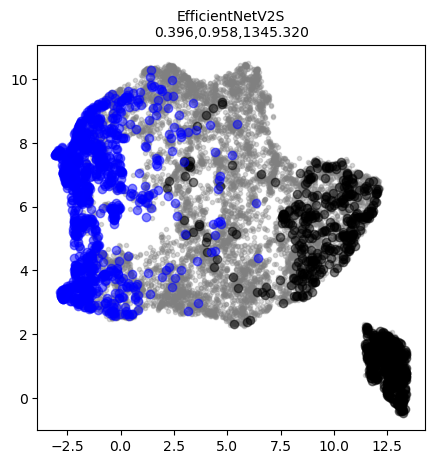

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [00:25<00:00,  2.70it/s]


In [800]:
# run umap from the features
sp = 'ent'
ftype_flip = 'nem'
ftype = ftype_flip.split('_')[0]
flip_type = "_"+ftype_flip.split('_')[1] if '_' in ftype_flip else ''
labels = lab[sp+'_lab'].to_numpy() # lab['ent_lab'].to_numpy()

pkl_path = clust_path+'model_selection_'+ftype+'/'

# load data

fig_path = clust_path+'figure_'+ftype+'/'
os.makedirs(fig_path, exist_ok=True)

npy_path = clust_path+'n_e_m_files/'
os.makedirs(npy_path, exist_ok=True)

# cluster_score_outfile = clust_path+sp+'_modsel_cluster_scores.txt'
# cluster_score_df = pd.DataFrame(columns=['model_name', 'slh', 'dbs', 'chs'])

# clust_num = 5

for model_name in tqdm(model_dictionary.keys()):
    if model_name not in curr_models[ftype]:
        continue
    if model_name == 'NASNetLarge' or model_name == 'ConvNeXtXLarge':
        continue
        
    print(ftype_flip + ' ' + model_name)

    print('loading pickle file')
    # load the features according to the feature keys (filenames) of ne
    feat_file = open(pkl_path + model_name + '_scaledfeat_' + ftype_flip + '_bg_res.pkl', 'rb')
    feat_dict = pickle.load(feat_file)
    feat = np.array([feat_dict[key] for key in sorted(feat_dict.keys())])  

    # run PCA
    print('running PCA')
    pca_file = npy_path + model_name + '_pca_' + ftype_flip
    pca_feat = get_pca_features(pca_file, 20, feat, 1)

    # generate umap
    print('generating umap')
    umap_file = npy_path + model_name + '_umap_' + ftype_flip
    embedding = get_umap_embedding(umap_file, pca_feat, 1)

#     # cluster using kmeans clustering
#     print('running kmeans clustering')
#     km_file = npy_path + model_name + '_kmeans' + str(clust_num) + '_' + ftype
#     kmlabels = get_kmeans_cluster(km_file, pca_feat, clust_num, 0)

    # silhouette score
    scores = get_cluster_score(feat.copy(), labels.copy());
 
    # plotting
    f = plt.figure(figsize=(5,5))
    plot_umap_sp(f, model_name, embedding, labels, ",".join(f"{score:.3f}" for score in scores))
    plt.show()
    f.savefig(fig_path+model_name+'_umap_'+sp+'clust_'+ftype+'.jpg')
    
# cluster_score_df.to_csv(cluster_score_outfile, index=False, sep='\t')

### Concatenate different models

nEfficientNetV2S_dInceptionV3
loading pickle file
running PCA
generating umap


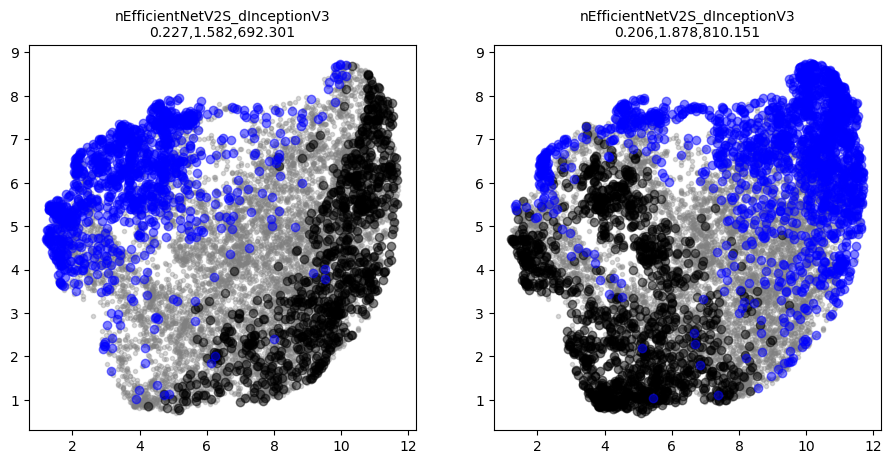

In [801]:
n_models = ['EfficientNetV2S'] # ['EfficientNetB3', 'EfficientNetB2', 'Xception', 'EfficientNetV2S', 'EfficientNetV2B1']
d_models = ['InceptionV3'] # []'InceptionV3, 'Xception', 'DenseNet201', 'DenseNet121', 'DenseNet169']

fig_path = clust_path+'figure_concat/'
os.makedirs(fig_path, exist_ok=True)

npy_path = clust_path+'n_e_m_files/'
os.makedirs(npy_path, exist_ok=True)

for n in n_models:
    for d in d_models:
        model_name = "n"+n+"_d"+d+''
        print(model_name)

        print('loading pickle file')
        # load the features according to the feature keys (filenames) of nem
        nem_feat = load_features_pkl(clust_path + 'model_selection_nem/' + n + '_scaledfeat_' + 'nem_bg_res.pkl')
        dot_feat = load_features_pkl(clust_path + 'model_selection_dota/' + d + '_scaledfeat_' + 'dota_bg_res.pkl')

        # concatenate the models
        feat = np.concatenate((nem_feat, dot_feat), axis=1)
        # run PCA
        print('running PCA')
        pca_file =  npy_path + model_name + '_pca'
        pca_feat = get_pca_features(pca_file, 20, feat, 0)

        # generate umap
        print('generating umap')
        umap_file = npy_path + model_name + '_umap'
        embedding = get_umap_embedding(umap_file, pca_feat, 0)

        # # cluster using kmeans clustering
        # print('running kmeans clustering')
        # km_file = npy_path + model_name + '_kmeans' + str(clust_num)
        # kmlabels = get_kmeans_cluster(km_file, pca_feat, clust_num, 0)

        # plotting
        f = plt.figure(figsize=(5,5))
        plot_umap_sp(f, model_name, embedding,, ",".join(f"{score:.3f}" for score in scores_ent))
        plt.show()
        f.savefig(fig_path+model_name+'_umap_entdenclust_nemden.jpg')

        plt.close()

# cluster_score_df.to_csv(cluster_score_outfile, index=False, sep='\t')

In [762]:
clust_path + 'model_selection_nem/' + n + '_scaledfeat_' + 'nem_bg_res.pkl'

'/lab_home/N417/Jen-Hao/Spatiotemporal/initiation_clustering/photoinduct_ini_150_bg8_res13_rotated_10_clust/model_selection_nem/EfficientNetV2S_scaledfeat_nem_bg_res.pkl'

### load the selected concatenated model

In [15]:
clust_path = "D:/Spatiotemporal_analysis/Initiation_clustering/photoinduct_ini_150_rotated_10_clust/"

In [13]:
n = 'EfficientNetV2S'
d = 'InceptionV3'

model_name =  'n'+n+'_'+'d'+d+''

fig_path = clust_path+'figure_concat/'
npy_path = clust_path+'n_e_m_files/'

umap_file = npy_path + model_name + '_umap.npy'
embedding = np.load(umap_file)

xmin, xmax, ymin, ymax = [min(embedding[:, 0])-1, max(embedding[:, 0])+1, min(embedding[:, 1])-1, max(embedding[:, 1])+1]

### run UMAP

(-0.9252833276987076, 9.553093910217285)

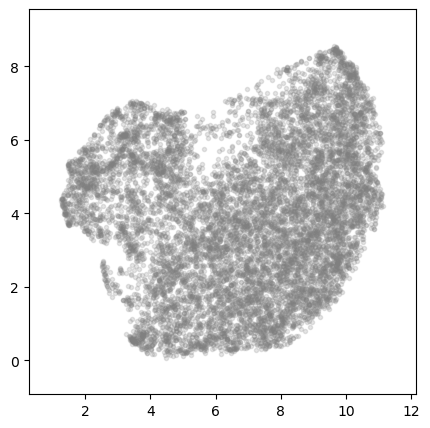

In [14]:
plt.figure(figsize=(5,5), edgecolor='w')
plt.plot(embedding[:,0],embedding[:,1],'.',markersize=6, color='gray', alpha=0.2)
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.show()
# plt.savefig(fig_path+model_name+'_all.jpg')

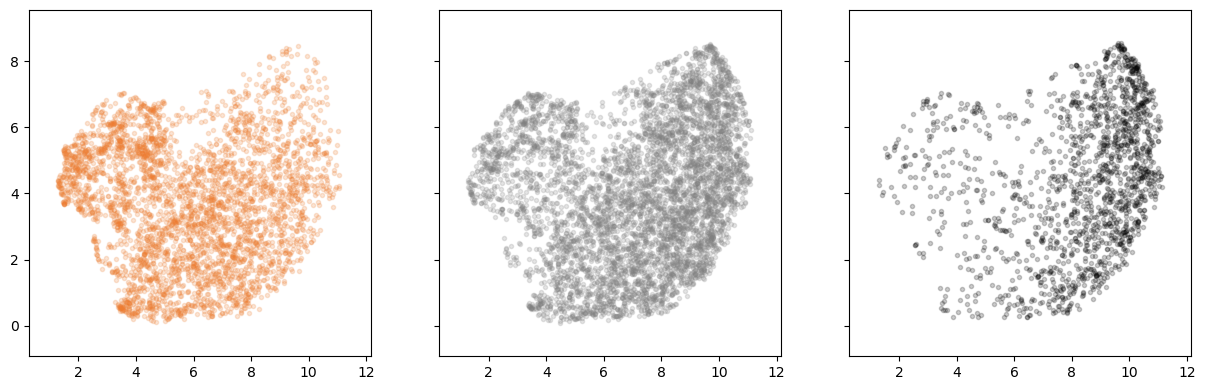

In [24]:
# plot the sources of initiation images
labels = lab['source'].to_numpy()

f, (axs) = plt.subplots(1,3, figsize=(15,4.5), sharex=True, sharey=True)
plt.setp(axs, xlim=[xmin, xmax], ylim=[ymin, ymax])

axs[0].plot(embedding[labels>=0,0], embedding[labels>=0,1],'.',  markersize=6, color='#ED7D31', alpha=0.2)  # spontaneous color: 'orange'
axs[1].plot(embedding[labels==-1,0],embedding[labels==-1,1],'.', markersize=6, color='gray', alpha=0.2) 
axs[2].plot(embedding[labels==-2,0],embedding[labels==-2,1],'.', markersize=6, color='black', alpha=0.2)

# plt.savefig(fig_path+model_name+'_inisources_all.svg')
# plt.savefig(fig_path+model_name+'_inisources_all.jpg')

(-0.9252833276987076, 9.553093910217285)

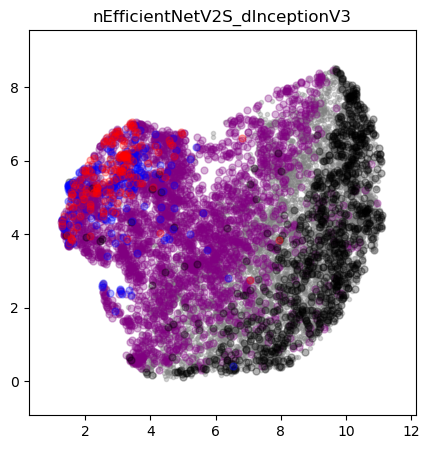

In [25]:
labels = lab['pattern'].to_numpy()

my_col  = {1:'red', 2:'blue', 3:'purple', 4:'purple', 5:'black', 6:'purple', 0: 'gray'}
my_marksz = {1:10, 2:10, 3:10, 4:10, 5:10, 6:10, 0:6}
my_alpha  = {1:0.3, 2:0.3, 3:0.4, 4:0.4, 5:0.4, 6:0.4, 0:0.3}

plt.figure(figsize=(5,5))
plt.title(model_name) 
for i in [0, 3, 4, 6, 5, 2, 1]:
    plt.plot(embedding[labels==i,0],embedding[labels==i,1],'.',markersize=my_marksz[i], color=my_col[i], alpha=0.3)
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.show()

# plt.savefig(fig_path+model_name+'_ini_pattern_all.jpg')

In [843]:
fig_path

'/lab_home/N417/Jen-Hao/Spatiotemporal/initiation_clustering/photoinduct_ini_150_bg8_res13_rotated_10_clust/figure_concat/'

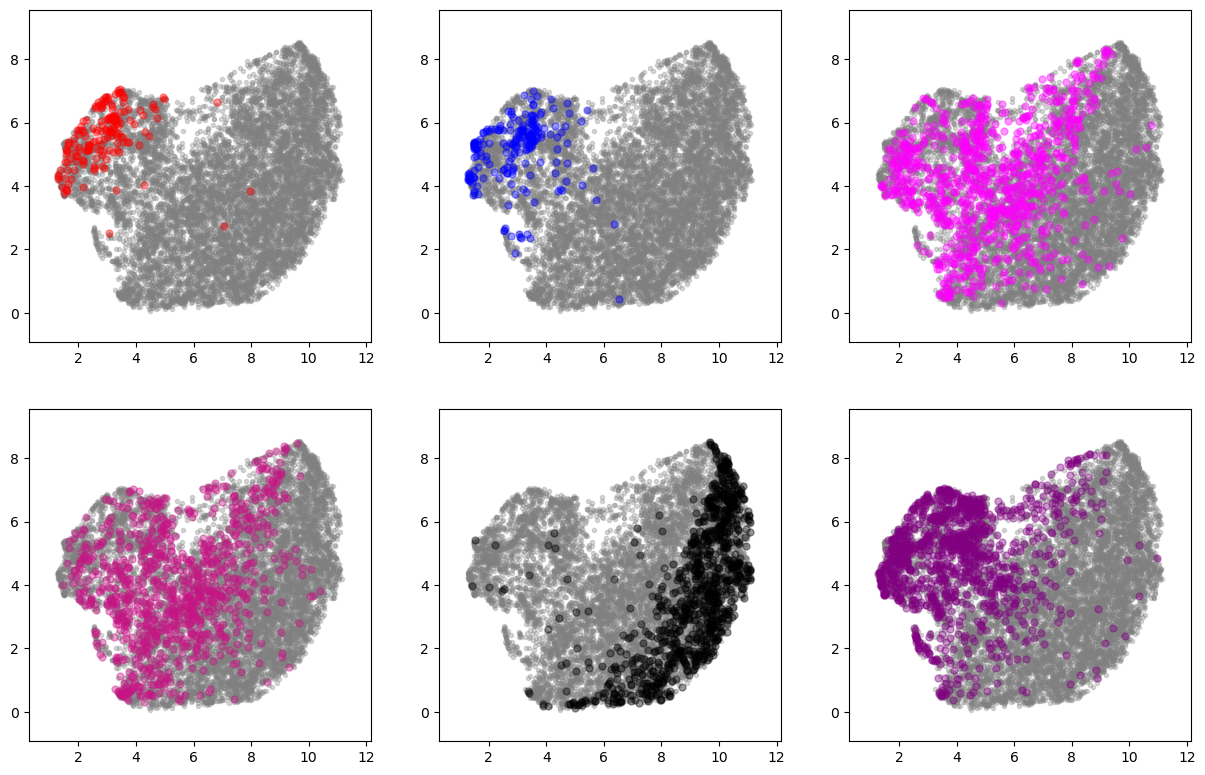

In [17]:
mycolor = {1: 'red', 2:'blue', 3:'magenta', 4:'mediumvioletred', 5:'black', 6:'purple'}
pattern = {1: 'phalf', 2:'mhalf', 3:'splay', 4:'bend', 5:'aligned', 6:'splay+bend'}

labels = lab['pattern'].to_numpy()

plt.figure(figsize=(15,9.5))
for pttn in range(1,7):
    plt.subplot(2,3,pttn)
    plt.plot(embedding[labels!=pttn,0],embedding[labels!=pttn,1],'.',markersize=6, color='gray', alpha=0.3)   
    plt.plot(embedding[labels==pttn,0],embedding[labels==pttn,1],'.',markersize=10, color=mycolor[pttn], alpha=0.4)
    plt.xlim([xmin, xmax])
    plt.ylim([ymin, ymax])
    
plt.savefig(fig_path+model_name+'_ini_pattern_allsingle.jpg')


### kernel density plot

In [26]:
points = [tuple(x) for x in embedding]

alpha_shape = alphashape.alphashape(points, 0.5)

labels = lab['source'].to_numpy()

nbins=300
xi, yi = np.mgrid[xmin:xmax:nbins*1j, ymin:ymax:nbins*1j]

# initiation
x, y = [embedding[labels>=0, 0], embedding[labels>=0, 1]]
k_ini = gaussian_kde([x,y], bw_method=0.21)
z_ini = k_ini(np.vstack([xi.flatten(), yi.flatten()]))

# non-initiation
x, y = [embedding[labels==-1, 0], embedding[labels==-1, 1]]
k_bg = gaussian_kde([x,y], bw_method=0.21)
z_bg = k_bg(np.vstack([xi.flatten(), yi.flatten()]))

# resistant region
x, y = [embedding[labels==-2, 0], embedding[labels==-2, 1]]
k_res = gaussian_kde([x,y], bw_method=0.21)
z_res = k_res(np.vstack([xi.flatten(), yi.flatten()]))

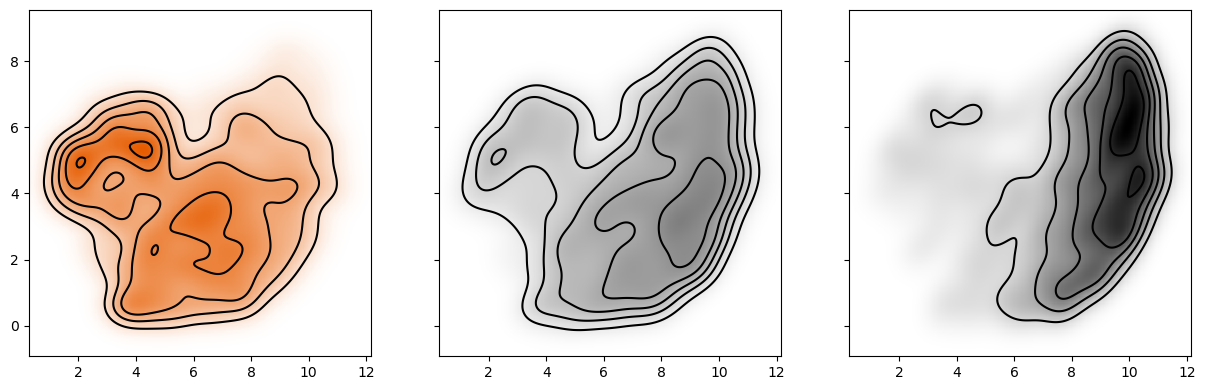

In [27]:
hex_color = '#E65C00'
rgb_color = mcolors.hex2color(hex_color)

mycmap1 = mcolors.LinearSegmentedColormap.from_list('custom_colormap', ['white', rgb_color])

# Create a colormap that use only the first half of the colormap
cmap = plt.get_cmap('binary')
mycmap2 = mcolors.LinearSegmentedColormap.from_list('half_cmap', cmap(np.linspace(0, 0.5, 256)))

# plotting
f, (axs) = plt.subplots(1,3, figsize=(15,4.5), sharex=True, sharey=True)
plt.setp(axs, xlim=[xmin, xmax], ylim=[ymin, ymax])

# plot initiation
axs[0].pcolormesh(xi, yi, z_ini.reshape(xi.shape), shading='auto', cmap=mycmap1)
axs[0].contour(xi, yi, z_ini.reshape(xi.shape), 5, colors='k')

# plot background
axs[1].pcolormesh(xi, yi, z_bg.reshape(xi.shape), shading='auto', cmap=mycmap2)
axs[1].contour(xi, yi, z_bg.reshape(xi.shape), 5, colors='k')

# plot resistant region
axs[2].pcolormesh(xi, yi, z_res.reshape(xi.shape), shading='auto', cmap='binary')
axs[2].contour(xi, yi, z_res.reshape(xi.shape), 5, colors='k')

# plt.savefig(fig_path+model_name+'_ini_bg_res_umapdensity.jpg')

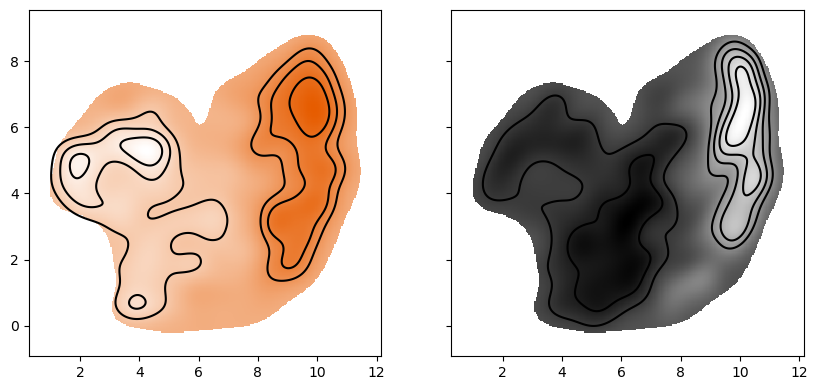

In [28]:
# set threshold of trimming the colormesh
z_idx = np.where(z_bg<0.004)[0]

# plot contour
min_val = min(xmin+1, ymin+1)
max_val = max(xmax+1, ymax+1)
scaled_z_ini = (z_ini - min_val) / (max_val - min_val)
scaled_z_bg = (z_bg - min_val) / (max_val - min_val)
scaled_z_res = (z_res - min_val) / (max_val - min_val)

z_ratio_ini = scaled_z_ini/scaled_z_bg
z_ratio_res = scaled_z_res/scaled_z_bg

f, (axs) = plt.subplots(1,2, figsize=(10,4.5), sharex=True, sharey=True)
plt.setp(axs, xlim=[xmin, xmax], ylim=[ymin, ymax])

# plot initiation
ini_lvl = np.linspace(np.nanmin(z_ratio_ini.reshape(xi.shape)), np.nanmax(z_ratio_ini.reshape(xi.shape)), 10)
ini_lvl = np.delete(ini_lvl, [4, 5])
axs[0].contour(xi, yi, z_ratio_ini.reshape(xi.shape), ini_lvl, colors='k')

z_ratio_ini_nonan = z_ratio_ini.copy()
z_ratio_ini_nonan[z_idx] = np.nan
axs[0].pcolormesh(xi, yi, z_ratio_ini_nonan.reshape(xi.shape), shading='auto', cmap=mycmap1)

# plot resistant region
res_lvl = np.linspace(np.nanmin(z_ratio_res.reshape(xi.shape)), np.nanmax(z_ratio_res.reshape(xi.shape)), 10)
res_lvl = np.delete(res_lvl, [5,6])
# res_lvl = np.delete(res_lvl, [2,3])
# res_lvl = np.delete(res_lvl, [5,6])
plt.contour(xi, yi, z_ratio_res.reshape(xi.shape), res_lvl, colors='k')

z_ratio_res_nonan = z_ratio_res.copy()
z_ratio_res_nonan[z_idx] = np.nan
plt.pcolormesh(xi, yi, z_ratio_res_nonan.reshape(xi.shape), shading='auto', cmap='gray_r')

# plt.savefig(fig_path+model_name+'_ini_bg_umapdensity.jpg')

### Show spatial properties on umap

In [29]:
# create a mapping series from 'fid' to 'ent'
mapping = df.set_index('fid')['ent']

# use map method to get values based on mapping
ent = pd.Series(fid).map(mapping).to_numpy()

# convert resulting series to numpy array
# ent = ent.to_numpy()
ent = ent + abs(np.nanmin(ent))
ent = (ent - np.nanmin(ent)) / (np.nanmax(ent) - np.nanmin(ent))

ent_idx = np.isnan(ent)
ent = ent[~ent_idx]

In [65]:
# create a mapping series from 'fid' to 'ent'
mapping = df.set_index('fid')['den']

# use map method to get values based on mapping
den = pd.Series(fid).map(mapping).to_numpy()

# convert resulting series to numpy array
# den = den.to_numpy()
den = den + abs(np.nanmin(den))
# den = (den - np.nanmin(den)) / (np.nanmax(den) - np.nanmin(den))

# only for coloring
den_2sd = np.nanmean(den) + 2* np.nanstd(den)
den[den>den_2sd] = den_2sd
den = (den - np.nanmin(den)) / (den_2sd - np.nanmin(den))

den_idx = np.isnan(den)
den = den[~den_idx]

In [58]:
model_name

'nEfficientNetV2S_dInceptionV3'

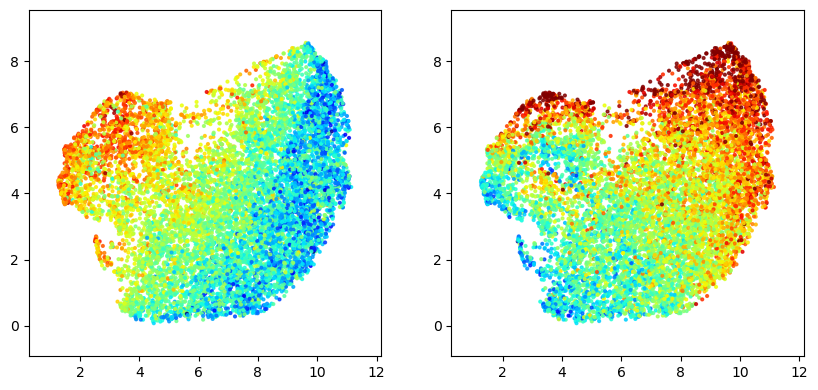

In [66]:
# umapx, umapy = [embedding[~(idx),0], embedding[~(idx),1]]
# labels_nonan = labels[~idx]

plt.figure(figsize=(10,4.5))
plt.subplot(1,2,1)
# plt.scatter(embedding[~(ent_idx),0],embedding[~(ent_idx),1], c=ent, s=4, cmap=plt.cm.afmhot.reversed(), alpha=0.8)
plt.scatter(embedding[~(ent_idx),0],embedding[~(ent_idx),1], c=ent, s=4, cmap=plt.cm.jet, alpha=0.8)
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.subplot(1,2,2)
# plt.scatter(embedding[~(den_idx),0],embedding[~(den_idx),1], c=den, s=4, cmap=plt.cm.afmhot.reversed(), alpha=0.8)
plt.scatter(embedding[~(den_idx),0],embedding[~(den_idx),1], c=den, s=4, cmap=plt.cm.jet, alpha=0.8)
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.colorbar()
plt.savefig(fig_path+model_name+'_sp_jet.svg')
plt.savefig(fig_path+model_name+'_sp_jet.jpg')

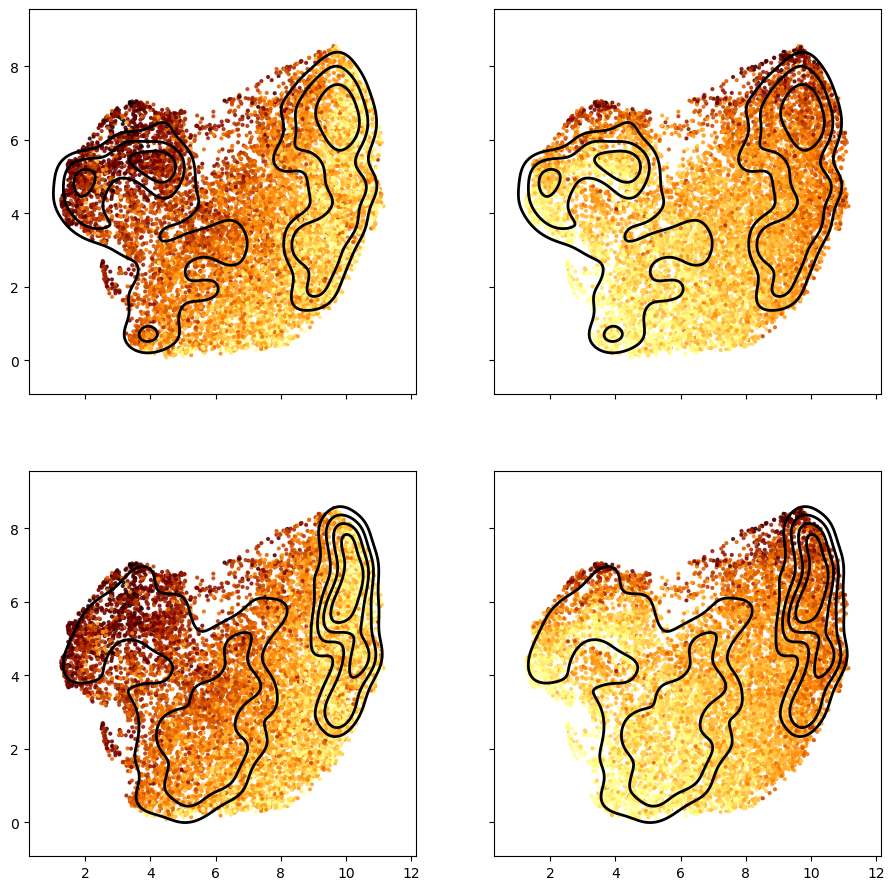

In [42]:
# plotting
f, (axs) = plt.subplots(2,2, figsize=(11,11), sharex=True, sharey=True)
plt.setp(axs, xlim=[xmin, xmax], ylim=[ymin, ymax])


# plot initiation contour
axs[0,0].scatter(embedding[~(ent_idx),0],embedding[~(ent_idx),1], c=ent, s=4, cmap=plt.cm.afmhot.reversed(), alpha=0.8)
axs[0,0].contour(xi, yi, z_ratio_ini.reshape(xi.shape), ini_lvl, linewidths=2, colors='k')

axs[0,1].scatter(embedding[~(den_idx),0],embedding[~(den_idx),1], c=den, s=4, cmap=plt.cm.afmhot.reversed(), alpha=0.8)
axs[0,1].contour(xi, yi, z_ratio_ini.reshape(xi.shape), ini_lvl, linewidths=2, colors='k')

# plot resistant contour
axs[1,0].scatter(embedding[~(ent_idx),0],embedding[~(ent_idx),1], c=ent, s=4, cmap=plt.cm.afmhot.reversed(), alpha=0.8)
axs[1,0].contour(xi, yi, z_ratio_res.reshape(xi.shape), res_lvl, linewidths=2, colors='k')

axs[1,1].scatter(embedding[~(den_idx),0],embedding[~(den_idx),1], c=den, s=4, cmap=plt.cm.afmhot.reversed(), alpha=0.8)
axs[1,1].contour(xi, yi, z_ratio_res.reshape(xi.shape), res_lvl, linewidths=2, colors='k')

# plt.savefig(fig_path+model_name+'_sp_contour.svg')
# plt.savefig(fig_path+model_name+'_sp_contour.jpg')

In [31]:
axs

array([[<AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: >, <AxesSubplot: >]], dtype=object)

### spatial properties scatter plot

In [11]:
is_registered = 0

if is_registered == 0:
    # get colormap
    ncolors = 256
    color_array = plt.get_cmap('Oranges')(range(ncolors))

    # change alpha values
    color_array[:,-1] = np.linspace(0.0,1.0,ncolors)

    # create a colormap object
    map_object = mcolors.LinearSegmentedColormap.from_list(name='oranges_alpha_r',colors=color_array)

    # register this new colormap with matplotlib
    plt.register_cmap(cmap=map_object)

In [12]:
nbins=300
xi, yi = np.mgrid[-4:1:nbins*1j, 20:160:nbins*1j] 

all_ent = np.concatenate((p_df['ent'].values, s_df['ent'].values), axis=None)
all_den = np.concatenate((p_df['den'].values, s_df['den'].values), axis=None)

all_ent_n = all_ent[~np.isnan(all_ent) & ~np.isnan(all_den)]
all_den_n = all_den[~np.isnan(all_ent) & ~np.isnan(all_den)]

k_ini = gaussian_kde([all_ent_n,all_den_n], bw_method=0.2)
z_ini = k_ini(np.vstack([xi.flatten(), yi.flatten()]))

res_ent = res_df['ent'].values
res_den = res_df['den'].values

res_ent_n = res_ent[~np.isnan(res_ent) & ~np.isnan(res_den)]
res_den_n = res_den[~np.isnan(res_ent) & ~np.isnan(res_den)]

k_res = gaussian_kde([res_ent_n, res_den_n], bw_method=0.3)
z_res = k_res(np.vstack([xi.flatten(), yi.flatten()]))

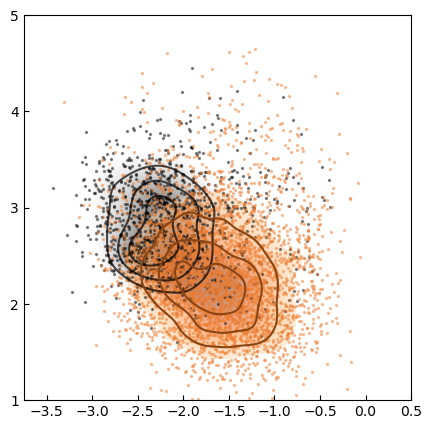

In [34]:
fig_path = clust_path+'figure_concat/'

plt.figure(figsize=(5,5))

# plt.scatter(bg_df['ent'], bg_df['den'], s=2, color='gray', alpha=0.2)

z_idx = np.where(z_res<0.005)[0]
temp_res=z_res
temp_res[z_idx] = np.nan
p_res_mesh = plt.pcolormesh(xi, yi, temp_res.reshape(xi.shape), shading='auto', cmap='Greys', alpha=0.5)

my_cmap = truncate_colormap(plt.cm.Oranges, 0.2, 1)
color_array
z_idx = np.where(z_ini<0.005)[0]
temp_ini=z_ini
temp_ini[z_idx] = np.nan
p_res_mesh = plt.pcolormesh(xi, yi, temp_ini.reshape(xi.shape), shading='auto', cmap=my_cmap, alpha=0.5)

plt.scatter(res_df['ent'], res_df['den'], s=2, color='black', alpha=0.4)
plt.scatter(s_df['ent'], s_df['den'], s=2, color='#ED7D31', alpha=0.4)
plt.scatter(p_df['ent'], p_df['den'], s=2, color='#ED7D31', alpha=0.4)
plt.contour(xi, yi, z_res.reshape(xi.shape), 3, colors='black', alpha=0.7)
plt.contour(xi, yi, z_ini.reshape(xi.shape), 3, colors='saddlebrown')

plt.tick_params(axis='y', direction='in')
plt.tick_params(axis='x', direction='in')
plt.xlim([-3.75,0.5])
# plt.ylim([20,160])
plt.ylim([28.27433388,141.3716694])

y_values = [28.27433388, 56.54866776, 84.82300165, 113.0973355, 141.3716694]
labels = ["1", "2", "3", "4", "5"]

plt.yticks(y_values, labels)
# plt.savefig(fig_path+model_name+'_entden_scatter_contour.svg')
# plt.savefig(fig_path+model_name+'_entden_scatter_contour.jpg')
# plt.savefig(fig_path+'spatio_scatter2d_allini_res11_ent_den_scaled3.pdf')